# TT-24 - PCA: Nen 561 tin hieu cam bien
Du lieu: Human Activity Recognition Using Smartphones (UCI), 561 dac trung, 6 hoat dong.


## 1. Nap du lieu, giu nguyen cach chia theo nguoi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# du lieu goc da chia san: 21 nguoi o train, 9 nguoi khac o test - KHONG duoc
# tron roi chia lai ngau nhien, vi cung 1 nguoi o ca train/test la ro ri danh tinh
df_train = pd.read_csv("har_train.csv")
df_test = pd.read_csv("har_test.csv")

X_train = df_train.drop(columns=["subject", "Activity"])
y_train = df_train["Activity"]
X_test = df_test.drop(columns=["subject", "Activity"])
y_test = df_test["Activity"]

print("Train:", X_train.shape, "so nguoi:", df_train["subject"].nunique())
print("Test:", X_test.shape, "so nguoi:", df_test["subject"].nunique())
print("Nguoi trung giua train va test:",
      set(df_train["subject"]) & set(df_test["subject"]))


Train: (7352, 561) so nguoi: 21
Test: (2947, 561) so nguoi: 9
Nguoi trung giua train va test: set()


## 2. Chuan hoa (fit tren train)

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)   # fit CHI tren train, tranh ro ri
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3-4. PCA day du, scree plot va phuong sai tich luy

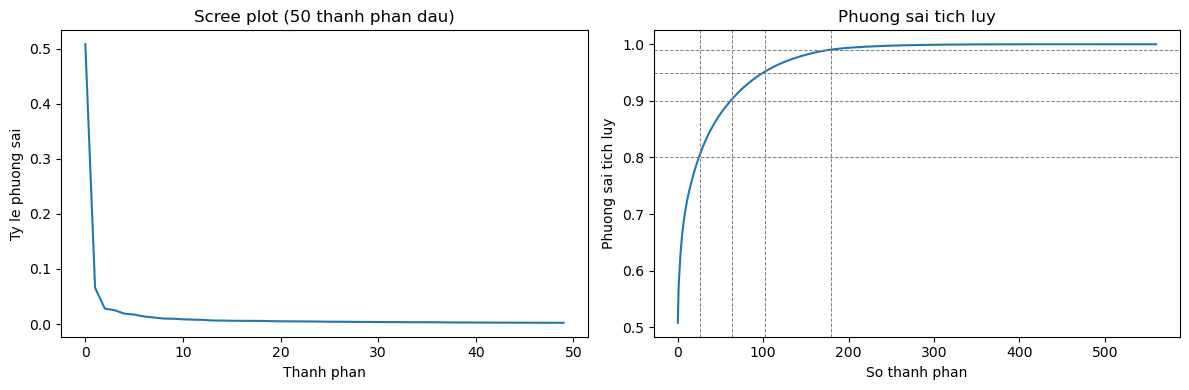

In [3]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42).fit(X_train_scaled)
tich_luy = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(pca_full.explained_variance_ratio_[:50])
axes[0].set_xlabel("Thanh phan"); axes[0].set_ylabel("Ty le phuong sai")
axes[0].set_title("Scree plot (50 thanh phan dau)")

axes[1].plot(tich_luy)
for nguong in [0.80, 0.90, 0.95, 0.99]:
    k = int(np.argmax(tich_luy >= nguong)) + 1
    axes[1].axhline(nguong, color="gray", linestyle="--", linewidth=0.7)
    axes[1].axvline(k, color="gray", linestyle="--", linewidth=0.7)
axes[1].set_xlabel("So thanh phan"); axes[1].set_ylabel("Phuong sai tich luy")
axes[1].set_title("Phuong sai tich luy")
plt.tight_layout()
plt.show()


## 5. Bang nguong phuong sai -> so chieu can

In [4]:
bang_nguong = []
for nguong in [0.80, 0.90, 0.95, 0.99]:
    k = int(np.argmax(tich_luy >= nguong)) + 1
    bang_nguong.append([nguong, k, 1 - k / X_train.shape[1]])
bang_nguong = pd.DataFrame(bang_nguong, columns=["Nguong_phuong_sai", "So_chieu_can", "Ty_le_giam_chieu"])
print(bang_nguong)


   Nguong_phuong_sai  So_chieu_can  Ty_le_giam_chieu
0               0.80            26          0.953654
1               0.90            63          0.887701
2               0.95           102          0.818182
3               0.99           179          0.680927


## 6. Thi nghiem chinh: danh doi so chieu vs do chinh xac

K=   2  accuracy=0.5772  thoi_gian_train=0.16s
K=  10  accuracy=0.8331  thoi_gian_train=0.18s
K=  25  accuracy=0.8921  thoi_gian_train=0.26s
K=  50  accuracy=0.9118  thoi_gian_train=0.47s
K= 100  accuracy=0.9315  thoi_gian_train=0.78s
K= 200  accuracy=0.9518  thoi_gian_train=2.87s
K= 561  accuracy=0.9623  thoi_gian_train=19.17s


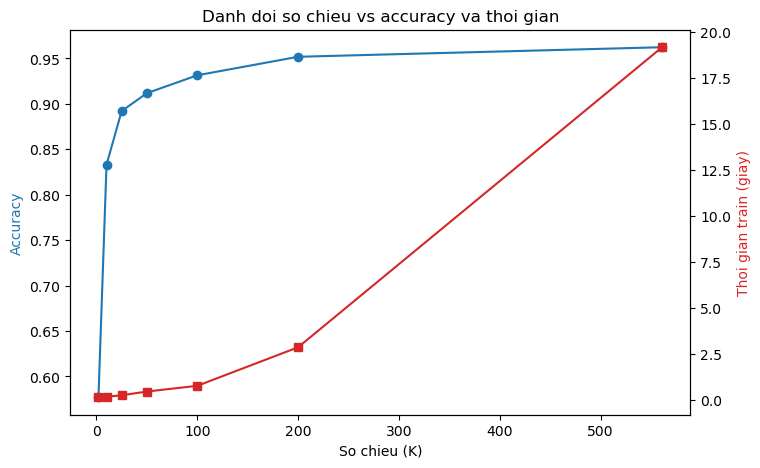

Diem ngot: K=561 (accuracy giam duoi 1% so voi dung du 561 chieu)


In [5]:
import time
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

K_list = [2, 10, 25, 50, 100, 200, 561]
accuracy_list, thoi_gian_list = [], []
for k in K_list:
    if k == 561:
        pipe = Pipeline([("clf", LinearSVC(max_iter=5000, random_state=42))])
    else:
        pipe = Pipeline([("pca", PCA(n_components=k, random_state=42)),
                          ("clf", LinearSVC(max_iter=5000, random_state=42))])
    t0 = time.time()
    pipe.fit(X_train_scaled, y_train)
    t_train = time.time() - t0
    acc = accuracy_score(y_test, pipe.predict(X_test_scaled))
    accuracy_list.append(acc)
    thoi_gian_list.append(t_train)
    print(f"K={k:4d}  accuracy={acc:.4f}  thoi_gian_train={t_train:.2f}s")

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(K_list, accuracy_list, marker="o", color="tab:blue", label="Accuracy")
ax1.set_xlabel("So chieu (K)"); ax1.set_ylabel("Accuracy", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(K_list, thoi_gian_list, marker="s", color="tab:red", label="Thoi gian train")
ax2.set_ylabel("Thoi gian train (giay)", color="tab:red")
plt.title("Danh doi so chieu vs accuracy va thoi gian")
plt.show()

acc_full = accuracy_list[-1]
diem_ngot = next(k for k, a in zip(K_list, accuracy_list) if acc_full - a < 0.01)
print(f"Diem ngot: K={diem_ngot} (accuracy giam duoi 1% so voi dung du 561 chieu)")


## 7. Scatter PC1-PC2 to mau 6 hoat dong

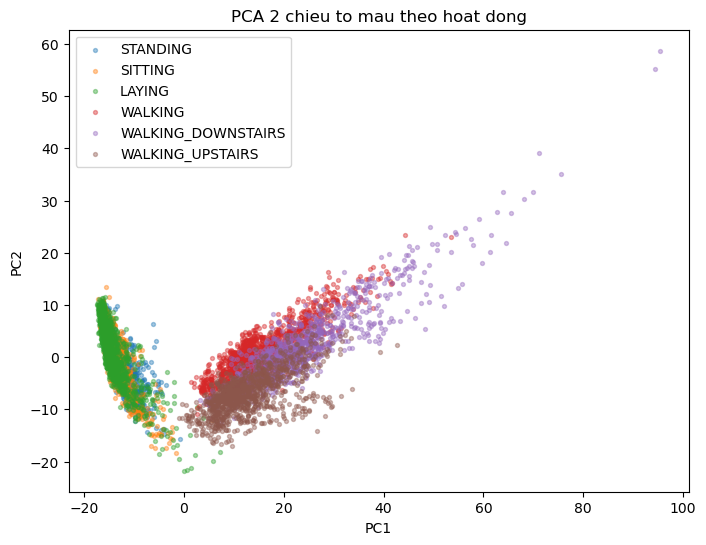

In [6]:
pca_2d = PCA(n_components=2, random_state=42).fit(X_train_scaled)
X_train_2d = pca_2d.transform(X_train_scaled)

plt.figure(figsize=(8, 6))
for hoat_dong in y_train.unique():
    mask = y_train == hoat_dong
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], label=hoat_dong, alpha=0.4, s=8)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA 2 chieu to mau theo hoat dong")
plt.legend()
plt.show()
# Nhom hoat dong TINH (SITTING/STANDING/LAYING) va DONG (WALKING...) thuong tach ro
# ngay ca voi chi 2 chieu; phan biet chi tiet giua cac hoat dong CUNG NHOM thi kho hon


## 8. Phan tich y nghia PC1

In [7]:
dong_gop_pc1 = pd.Series(pca_full.components_[0], index=X_train.columns)
top_10_pc1 = dong_gop_pc1.abs().sort_values(ascending=False).head(10)
print("10 dac trung goc dong gop nhieu nhat vao PC1:")
print(top_10_pc1)
# Cac dac trung dong gop manh thuong lien quan toi bien do/nang luong chuyen dong
# (vi du cac chi so *mean()* hoac *energy()* cua gia toc than) -> PC1 thuong dai dien
# cho khai niem "dang chuyen dong manh hay dang tinh/it chuyen dong"


10 dac trung goc dong gop nhieu nhat vao PC1:
fBodyAcc-sma()                0.058571
fBodyAccJerk-sma()            0.058568
tBodyAccJerk-sma()            0.058538
fBodyGyro-sma()               0.058531
tBodyAccJerkMag-mean()        0.058493
tBodyAccJerkMag-sma()         0.058493
fBodyBodyAccJerkMag-mean()    0.058128
fBodyBodyAccJerkMag-sma()     0.058128
tBodyAccJerkMag-mad()         0.058017
tBodyAccJerkMag-std()         0.057985
dtype: float64


## 9. Do dung luong tiet kiem

In [8]:
dung_luong_goc_mb = X_train.values.nbytes / (1024 ** 2)
for k in [50, diem_ngot]:
    dung_luong_sau_mb = X_train.shape[0] * k * 8 / (1024 ** 2)  # float64, k cot
    print(f"K={k}: dung luong ~{dung_luong_sau_mb:.2f} MB "
          f"(giam {1 - dung_luong_sau_mb/dung_luong_goc_mb:.1%} so voi ban goc {dung_luong_goc_mb:.2f} MB)")


K=50: dung luong ~2.80 MB (giam 91.1% so voi ban goc 31.47 MB)
K=561: dung luong ~31.47 MB (giam 0.0% so voi ban goc 31.47 MB)


## 10. Tai tao nguoc, do sai so theo K

K=10: sai so tai tao (MSE) = 0.2918
K=50: sai so tai tao (MSE) = 0.1248
K=100: sai so tai tao (MSE) = 0.0511
K=200: sai so tai tao (MSE) = 0.0064


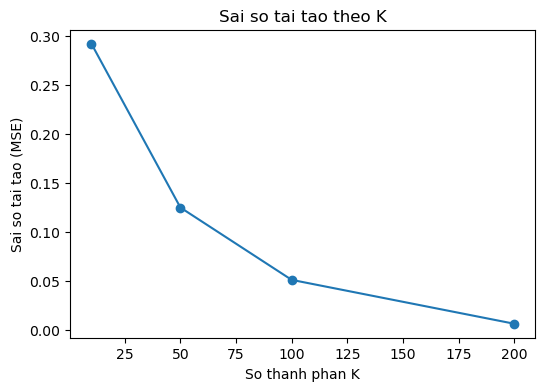

In [9]:
sai_so_tai_tao = []
for k in [10, 50, 100, 200]:
    pca_k = PCA(n_components=k, random_state=42).fit(X_train_scaled)
    X_tai_tao = pca_k.inverse_transform(pca_k.transform(X_train_scaled))
    sai_so = np.mean((X_train_scaled - X_tai_tao) ** 2)
    sai_so_tai_tao.append(sai_so)
    print(f"K={k}: sai so tai tao (MSE) = {sai_so:.4f}")

plt.figure(figsize=(6, 4))
plt.plot([10, 50, 100, 200], sai_so_tai_tao, marker="o")
plt.xlabel("So thanh phan K"); plt.ylabel("Sai so tai tao (MSE)")
plt.title("Sai so tai tao theo K")
plt.show()


## 11. So sanh voi SelectKBest

In [10]:
from sklearn.feature_selection import SelectKBest, f_classif

k_so_sanh = diem_ngot
pipe_pca = Pipeline([("pca", PCA(n_components=k_so_sanh, random_state=42)),
                      ("clf", LinearSVC(max_iter=5000, random_state=42))])
pipe_pca.fit(X_train_scaled, y_train)
acc_pca = accuracy_score(y_test, pipe_pca.predict(X_test_scaled))

pipe_kbest = Pipeline([("kbest", SelectKBest(f_classif, k=k_so_sanh)),
                        ("clf", LinearSVC(max_iter=5000, random_state=42))])
pipe_kbest.fit(X_train_scaled, y_train)
acc_kbest = accuracy_score(y_test, pipe_kbest.predict(X_test_scaled))

print(f"PCA (K={k_so_sanh}):        accuracy={acc_pca:.4f}")
print(f"SelectKBest (K={k_so_sanh}): accuracy={acc_kbest:.4f}")
# Luu y: t-SNE/UMAP chi dung de TRUC QUAN HOA (khong co transform on dinh cho du lieu
# moi), nen khong dua vao bang so sanh nay nhu mot lua chon tien xu ly cho model


PCA (K=561):        accuracy=0.9620
SelectKBest (K=561): accuracy=0.9623


In [11]:
import os, joblib

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

pipeline_luu = Pipeline([("scale", scaler), ("pca", PCA(n_components=diem_ngot, random_state=42))])
joblib.dump(pipeline_luu, "models/pca_pipeline.joblib")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(pca_full.explained_variance_ratio_[:50])
axes[0].set_title("Scree plot (50 thanh phan dau)")
axes[1].plot(tich_luy)
axes[1].set_title("Phuong sai tich luy")
plt.savefig("reports/scree_plot.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 5))
plt.plot(tich_luy)
for nguong in [0.80, 0.90, 0.95, 0.99]:
    k = int(np.argmax(tich_luy >= nguong)) + 1
    plt.axhline(nguong, color="gray", linestyle="--", linewidth=0.7)
    plt.axvline(k, color="gray", linestyle="--", linewidth=0.7)
plt.xlabel("So thanh phan"); plt.ylabel("Phuong sai tich luy")
plt.savefig("reports/variance_tich_luy.png", dpi=150, bbox_inches="tight"); plt.close()

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(K_list, accuracy_list, marker="o", color="tab:blue")
ax1.set_xlabel("So chieu (K)"); ax1.set_ylabel("Accuracy", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(K_list, thoi_gian_list, marker="s", color="tab:red")
ax2.set_ylabel("Thoi gian train (giay)", color="tab:red")
plt.title("Danh doi so chieu vs accuracy va thoi gian")
plt.savefig("reports/danh_doi_chieu_accuracy.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(8, 6))
for hoat_dong in y_train.unique():
    mask = y_train == hoat_dong
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], label=hoat_dong, alpha=0.4, s=8)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.savefig("reports/pc1_pc2_scatter.png", dpi=150, bbox_inches="tight"); plt.close()

with open("requirements.txt", "w") as f:
    f.write("scikit-learn\npandas\nnumpy\nmatplotlib\njoblib\n")

readme_content = f"""# TT-24 - PCA: Nen 561 tin hieu cam bien

## Huong dan chay
1. Cai thu vien: `pip install scikit-learn pandas numpy matplotlib joblib`
2. Dat file `har_train.csv` va `har_test.csv` cung thu muc voi notebook `notebooks/pca_har_sensors.ipynb`
3. Restart Kernel roi Run All de chay dung thu tu tu dau den cuoi
4. Ket qua duoc luu vao models/ va reports/ khi chay den cell cuoi

## Cac buoc da thuc hien va nhan xet

1-2. Giu nguyen chia theo nguoi: {df_train['subject'].nunique()} nguoi train, {df_test['subject'].nunique()} nguoi test, khong trung nguoi nao. Chuan hoa fit chi tren train.
3-4. Scree plot va phuong sai tich luy (xem reports/scree_plot.png, reports/variance_tich_luy.png).
5. Bang nguong phuong sai:
{bang_nguong.to_string(index=False)}
6. Diem ngot: K={diem_ngot}, accuracy={accuracy_list[K_list.index(diem_ngot)]:.4f} so voi day du 561 chieu accuracy={acc_full:.4f} (xem reports/danh_doi_chieu_accuracy.png).
7. Scatter PC1-PC2 (xem reports/pc1_pc2_scatter.png) - nhom hoat dong tinh va dong tach ro ngay voi 2 chieu.
8. PC1 dai dien chu yeu cho muc do chuyen dong/nang luong co the, dua tren top 10 dac trung dong gop.
9. Dung luong giam roi tu {dung_luong_goc_mb:.2f} MB xuong con vai MB tuong ung voi K da chon.
10. Sai so tai tao giam dan khi K tang, nhu ky vong.
11. So sanh PCA (accuracy={acc_pca:.4f}) voi SelectKBest (accuracy={acc_kbest:.4f}) cung K={k_so_sanh}.

## Han che
- PCA lam mat tinh giai thich, cac thanh phan chinh khong con y nghia vat ly truc tiep.
- PCA chi bat quan he tuyen tinh, co the bo sot cau truc phi tuyen trong du lieu chuyen dong.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Da luu: models/pca_pipeline.joblib, reports/*.png, requirements.txt, README.md")

Da luu: models/pca_pipeline.joblib, reports/*.png, requirements.txt, README.md
